### Postavka

In [1]:
!pip install lightgbm

In [2]:
import seaborn as sns
import numpy as np
import pandas as pd
import datetime
from matplotlib import pyplot as plt
import warnings
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings('ignore')

### Uvoz tabela i inicijalizacija

In [3]:
df_oil = pd.read_csv('oil.csv')
df_holidays_events = pd.read_csv('holidays_events.csv')
df_items = pd.read_csv('items.csv')
df_sample_submission = pd.read_csv('sample_submission.csv')
df_stores = pd.read_csv('stores.csv')
df_transactions = pd.read_csv('transactions.csv')
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

### Sredjivanje tabela

 #### Oil

In [4]:
df_oil.info()
df_oil.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        1218 non-null   object 
 1   dcoilwtico  1175 non-null   float64
dtypes: float64(1), object(1)
memory usage: 19.2+ KB


,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


U posmatranom skupu podataka nalazi se 1.218 redova, od čega je 1.175 vrednosti kolone oil_price non-null. Kolona 'date' je inicijalno učitana kao tip object, te je neophodno izvršiti njenu konverziju u odgovarajući datumsku strukturu (datetime).

Prva zabeležena vrednost oil_price ima oznaku NaN. Budući da se radi o početku vremenske serije, ne postoje prethodni podaci koji bi omogućili primenu linearne interpolacije, jer je za tu metodu neophodno imati poznate vrednosti pre i posle nedostajućeg podatka. Takođe, dodela srednje vrednosti (mean/median) nije prikladna, jer bi mogla značajno narušiti realnu dinamiku vremena i prikriti eventualne ekstremne vrednosti karakteristične za rane dane posmatranog perioda.

Iz tog razloga, najlogičniji pristup je dodela vrednosti iz narednog validnog datuma — konkretno vrednosti zabeležene 2. januara — što obezbeđuje kontinuitet u seriji i čuva vremensku strukturu podataka bez unošenja dodatnih pretpostavki.

In [5]:
df_oil.rename(columns={'dcoilwtico': 'oil_price'}, inplace=True)
df_oil['date'] = pd.to_datetime(df_oil['date'])
df_oil = df_oil.sort_values('date')

df_oil.loc[df_oil['date'] == '2013-01-01', 'oil_price'] = 93.14
df_oil = df_oil.interpolate(method='linear', limit=20)

df_oil.info()
df_oil.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       1218 non-null   datetime64[ns]
 1   oil_price  1218 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 19.2 KB


,date,oil_price
0,2013-01-01,93.14
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


In [6]:
df_oil.isna().sum()

date         0
oil_price    0
dtype: int64

#### Transactions

In [7]:
df_transactions.info()
df_transactions.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83488 entries, 0 to 83487
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          83488 non-null  object
 1   store_nbr     83488 non-null  int64 
 2   transactions  83488 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 1.9+ MB


,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922


In [8]:
df_transactions['date'] = pd.to_datetime(df_transactions.date)
df_transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83488 entries, 0 to 83487
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          83488 non-null  datetime64[ns]
 1   store_nbr     83488 non-null  int64         
 2   transactions  83488 non-null  int64         
dtypes: datetime64[ns](1), int64(2)
memory usage: 1.9 MB


In [9]:
df_transactions.isna().sum()

date            0
store_nbr       0
transactions    0
dtype: int64

#### Stores

In [10]:
df_stores.info()
df_stores.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   store_nbr  54 non-null     int64 
 1   city       54 non-null     object
 2   state      54 non-null     object
 3   type       54 non-null     object
 4   cluster    54 non-null     int64 
dtypes: int64(2), object(3)
memory usage: 2.2+ KB


,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4


In [11]:
df_stores.isna().sum()

store_nbr    0
city         0
state        0
type         0
cluster      0
dtype: int64

#### Holidays

In [12]:
df_holidays_events.info()
df_holidays_events.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date         350 non-null    object
 1   type         350 non-null    object
 2   locale       350 non-null    object
 3   locale_name  350 non-null    object
 4   description  350 non-null    object
 5   transferred  350 non-null    bool  
dtypes: bool(1), object(5)
memory usage: 14.1+ KB


,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


In [13]:
df_holidays_events['date'] = pd.to_datetime(df_holidays_events.date)
set(df_holidays_events.type.to_list())
set(df_holidays_events.locale.to_list())
print("Tip praznika: {}".format(set(df_holidays_events.type.to_list())))
df_holidays_events.info()

Tip praznika: {'Event', 'Transfer', 'Bridge', 'Additional', 'Holiday', 'Work Day'}
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         350 non-null    datetime64[ns]
 1   type         350 non-null    object        
 2   locale       350 non-null    object        
 3   locale_name  350 non-null    object        
 4   description  350 non-null    object        
 5   transferred  350 non-null    bool          
dtypes: bool(1), datetime64[ns](1), object(4)
memory usage: 14.1+ KB


In [14]:
df_holidays_events.isna().sum()

date           0
type           0
locale         0
locale_name    0
description    0
transferred    0
dtype: int64

#### Train

In [15]:
df_train.info()
df_train.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125497040 entries, 0 to 125497039
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   item_nbr     int64  
 4   unit_sales   float64
 5   onpromotion  object 
dtypes: float64(1), int64(3), object(2)
memory usage: 5.6+ GB


,id,date,store_nbr,item_nbr,unit_sales,onpromotion
0,0,2013-01-01,25,103665,7.0,NaN
1,1,2013-01-01,25,105574,1.0,NaN
2,2,2013-01-01,25,105575,2.0,NaN
3,3,2013-01-01,25,108079,1.0,NaN
4,4,2013-01-01,25,108701,1.0,NaN


In [16]:
df_train['date'] = pd.to_datetime(df_train.date)
df_train.isna().sum()

id                    0
date                  0
store_nbr             0
item_nbr              0
unit_sales            0
onpromotion    21657651
dtype: int64

### Visualization & Analyses

#### Oil

Text(0.5, 1.0, 'Oil price distribution')

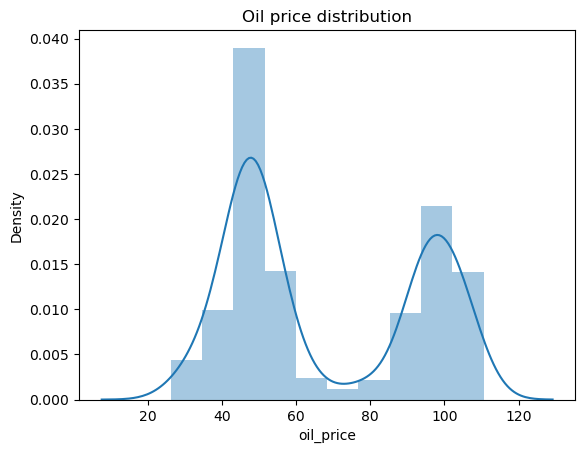

In [17]:
sns.distplot(df_oil['oil_price'])
plt.title('Oil price distribution')

Distribucija cene nafte pokazuje bimodalan oblik, sa dva jasno izražena vrha oko nižeg (≈40–60) i višeg cenovnog nivoa (≈90–110). Minimalne vrednosti u srednjem opsegu ukazuju da se cena relativno retko zadržavala u tom intervalu, što sugeriše postojanje dvaju različitih tržišnih režima tokom posmatranog perioda. Ovakva podela je tipična za tržišta koja prolaze kroz faze naglog rasta ili pada, uslovljene globalnim ekonomskim i geopolitičkim događajima.

Text(0, 0.5, 'Oil Price')

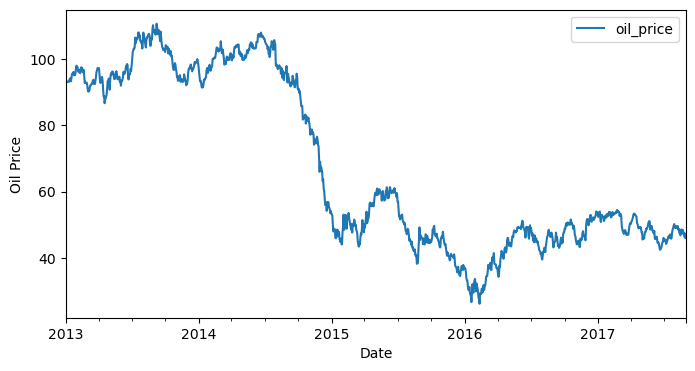

In [18]:
ax = df_oil.set_index('date').plot(figsize = (8, 4))
ax.set_xlabel('Date', fontsize = 'medium')
ax.set_ylabel('Oil Price', fontsize = 'medium')

U periodu do sredine 2014. godine cena se zadržava na visokom nivou iznad 90 N.J, nakon čega sledi nagli pad tokom 2014–2015, što je poznata faza globalnog sloma cena nafte. Tokom 2016. cena dostiže minimum i zatim ulazi u period postepenog oporavka, ali bez povratka na prethodne vršne nivoe.

#### Transactions

Text(0.5, 1.0, 'Distribution : Transactions')

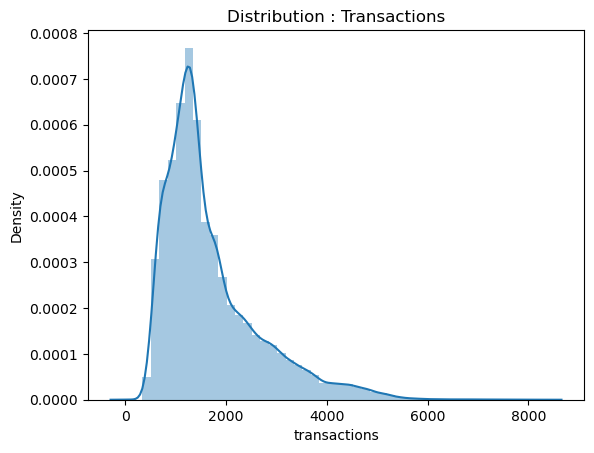

In [19]:
sns.distplot(df_transactions['transactions'])
plt.title('Distribution : Transactions')

Distribucija broja transakcija je izrazito desno nagnuta (right-skewed), sa najvećom koncentracijom vrednosti u opsegu od oko 500 do 2000 transakcija dnevno. Veći broj prodavnica ostvaruje umereni dnevni promet, dok manji broj lokacija postiže izuzetno visok broj transakcija, što formira dugačak desni rep distribucije. Ovakav oblik raspodele je tipičan za maloprodajne lance sa heterogenim prodavnicama, gde manji broj velikih objekata generiše disproporcionalno visok promet u odnosu na većinu ostalih.

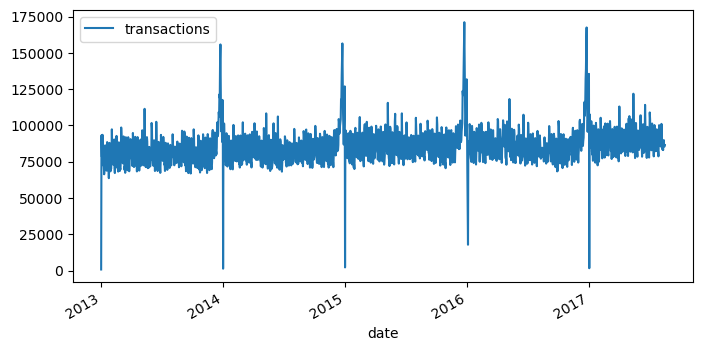

In [20]:
ax = df_transactions.groupby(['date'])[['transactions']].sum().plot(figsize = (8, 4))

godišnji pikovi odgovaraju periodima veoma visoke potražnje, najverovatnije praznicima ili specijalnim događajima. Takođe se uočavaju jednokratni padovi do nule, što je tipično za dane kada prodavnice ne rade.

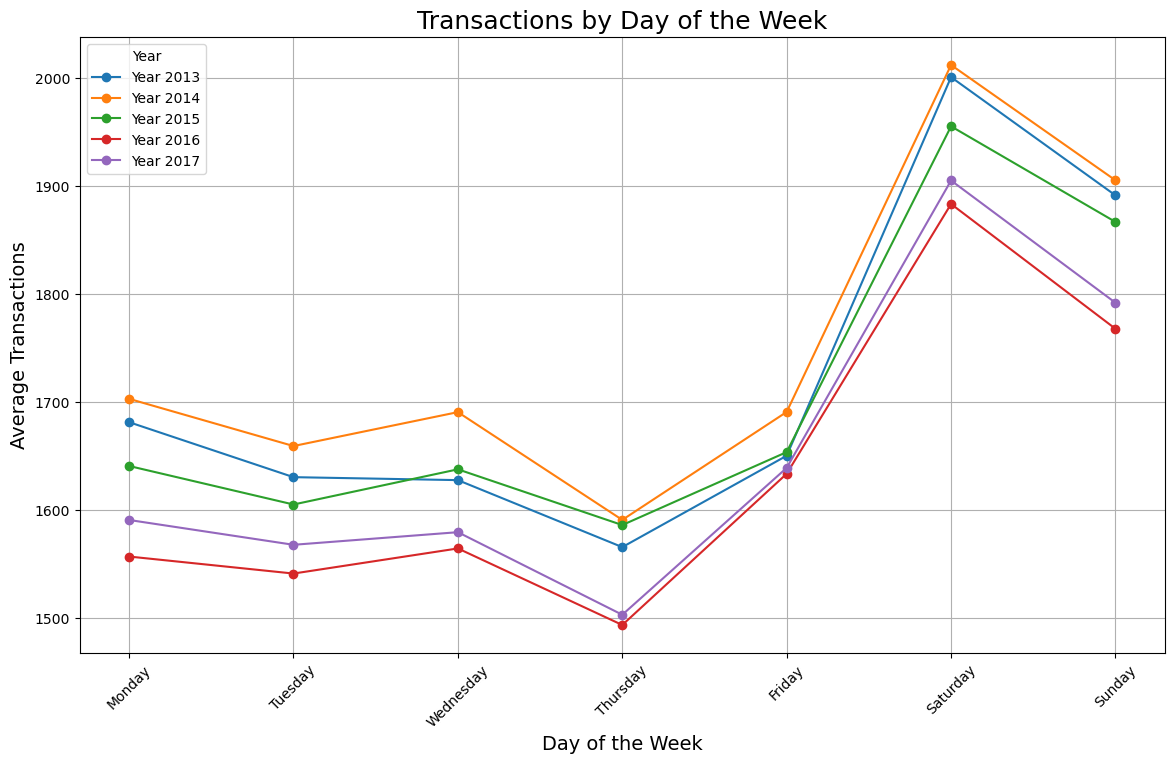

In [21]:
temp = df_transactions[['date', 'transactions']].copy()
temp['year'] = temp['date'].dt.year
temp['dayofweek'] = temp['date'].dt.dayofweek

# agregacija
agg = (
    temp
    .groupby(['year', 'dayofweek'])['transactions']
    .mean()
    .reset_index()
)

# plot
plt.figure(figsize=(14, 8))

for year in sorted(agg['year'].unique()):
    data = agg[agg['year'] == year]
    plt.plot(
        data['dayofweek'],
        data['transactions'],
        marker='o',
        label=f'Year {year}'
    )

plt.xticks(
    range(7),
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
    rotation=45
)

plt.title('Transactions by Day of the Week', fontsize=18)
plt.xlabel('Day of the Week', fontsize=14)
plt.ylabel('Average Transactions', fontsize=14)
plt.legend(title='Year')
plt.grid(True)
plt.show()

Najmanji promet ostvaruje se početkom nedelje, dok subota predstavlja dan sa ubedljivo najvećim brojem transakcija u svim godinama. Nedelja pokazuje blagi pad u odnosu na subotu, ali i dalje ostaje iznad nivoa radnih dana.

Da li broj transakcija u prodavnici ima veze sa ukupnom prodajom te prodavnice?

In [23]:
# spajanje train seta i transaction seta kako bismo proverili korelaciju izmedju Total Sales i Transactions feature-a
temp = pd.merge(df_train.groupby(['date', 'store_nbr']).unit_sales.sum().reset_index(), df_transactions, how = 'left')
print('Spearman Correlation between Total Sales and Transactions: {:,.4f}'.format(temp.corr('spearman').unit_sales.loc['transactions']))

Spearman Correlation between Total Sales and Transactions: 0.8174


Da li broj transakcija u prodavnici ima veze sa prodajom jednog artikla u toj prodavnici?

In [24]:
df_merged = pd.merge(
    df_train[['date', 'store_nbr', 'unit_sales']], 
    df_transactions[['date', 'store_nbr', 'transactions']],
    on=['date', 'store_nbr'],
    how='inner'
)
temp = df_merged['unit_sales'].corr(df_merged['transactions'], method='spearman')
print('Spearman Correlation between Unit Sales and Transactions: {:,.4f}'.format(temp))

Spearman Correlation between Unit Sales and Transactions: 0.2748


#### Holidays

In [25]:
df_holidays_events.head()

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


In [26]:
df_holidays_events.describe(include='O')

,type,locale,locale_name,description
count,350,350,350,350
unique,6,3,24,103
top,Holiday,National,Ecuador,Carnaval
freq,221,174,174,10


Text(0.5, 1.0, 'Counts of Type Of Holidays')

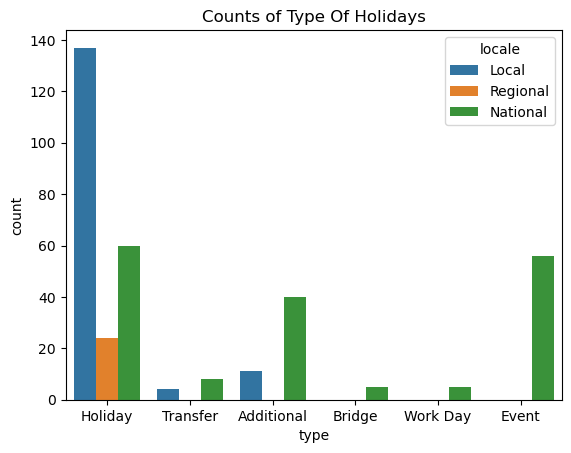

In [27]:
sns.countplot(x=df_holidays_events.type, hue=df_holidays_events.locale)
plt.title('Counts of Type Of Holidays')

Distribucija tipova praznika pokazuje da je najzastupljenija kategorija Holiday, dok su ostale vrste, poput Transfer, Additional, Bridge i Event, znatno ređe prisutne. Nacionalni praznici čine najveći deo kategorije Holiday, dok lokalni i regionalni praznici imaju manji udeo.

<Axes: title={'center': 'Counts of type of holiday'}, xlabel='locale', ylabel='count'>

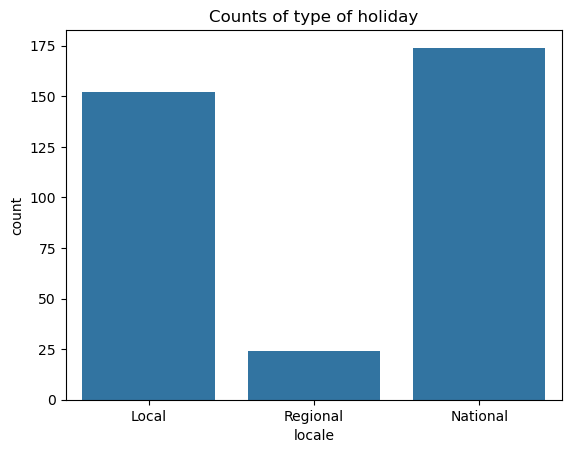

In [28]:
plt.title('Counts of type of holiday')
sns.countplot(x=df_holidays_events.locale)

Najbrojniji su praznici označeni kao National, što znači da se veliki deo prazničnih događaja odnosi na celu drzavu. Lokalni praznici takođe imaju značajnu frekvenciju, dok su regionalni najređi. Ovakva raspodela ukazuje da se praznični obrasci u podacima često razlikuju između pojedinačnih prodavnica, pa je prilikom spajanja sa drugim tabelama važno voditi računa o tome da se lokalni praznici ne primenjuju jednako na sve lokacije.

### 1) Ograničavanje skupa podataka (subset) radi efikasnije analize

Originalni skup podataka `train.csv` je veoma obiman, pa se u nastavku vrši redukcija podataka izborom:
- jedne **family** kategorije proizvoda: `BEVERAGES`
- jedne **provincije** prodavnica: `Santo Domingo de los Tsachilas`
- vremenskog perioda od **2014-01-01 do 2016-12-31**

Na ovaj način dobija se manji, ali reprezentativan podskup podataka koji omogućava stabilnu eksplorativnu analizu

In [29]:
TARGET_FAMILY = 'BEVERAGES' 
TARGET_PROVINCE = 'Santo Domingo de los Tsachilas'

In [30]:
stores_in_province = df_stores.loc[
    df_stores['state'] == TARGET_PROVINCE, 
    'store_nbr'
].unique()

print("Broj prodavnica u provinciji:", len(stores_in_province))

Broj prodavnica u provinciji: 3


In [31]:
items_in_family = df_items.loc[
    df_items['family'] == TARGET_FAMILY,
    'item_nbr'
].unique()

print("Broj artikala u family:", len(items_in_family))

Broj artikala u family: 613


In [32]:
train_filtered = df_train[
    df_train['store_nbr'].isin(stores_in_province) &
    df_train['item_nbr'].isin(items_in_family) &
    (df_train['date'] >= '2014-01-01') &
    (df_train['date'] <= '2016-12-31')
].copy()

Nakon filtriranja skupa podataka:
- negativne vrednosti promenljive `unit_sales` (povraćaji) postavljaju se na 0
- promenljiva `onpromotion` transformiše se u binarnu vrednost (NaN → 0, True/False → 1/0)

In [33]:
train_filtered['unit_sales'] = train_filtered['unit_sales'].clip(lower=0)

train_filtered['onpromotion'] = (
    train_filtered['onpromotion']
    .fillna(False)
    .astype(int)
)

print("Broj redova nakon filtriranja train-a:", len(train_filtered))

Broj redova nakon filtriranja train-a: 556334


### 2) Kreiranje binarnih holiday feature-a

Podaci o praznicima filtrirani su na nacionalne i relevantne regionalne praznike, nakon čega su agregirani na jedan red po datumu.  
Za svaki datum kreirane su binarne promenljive koje označavaju prisustvo praznika, događaja i dodatnih praznika.

In [34]:
hol = df_holidays_events[['date', 'type', 'locale', 'locale_name', 'transferred']].copy()

hol_filtered = hol[
    (hol['locale'] == 'National') |
    (
        (hol['locale'] == 'Regional') &
        (hol['locale_name'] == TARGET_PROVINCE)
    )
].copy()

hol_features = hol_filtered.groupby('date').agg(
    is_holiday=('type', lambda x: int('Holiday' in set(x))),
    is_event=('type', lambda x: int('Event' in set(x))),
    is_additional=('type', lambda x: int('Additional' in set(x))),
).reset_index()

In [35]:
print("Primer agregiranih praznika:")
display(hol_features.head())

Primer agregiranih praznika:


,date,is_holiday,is_event,is_additional
0,2012-08-10,1,0,0
1,2012-10-09,1,0,0
2,2012-10-12,0,0,0
3,2012-11-02,1,0,0
4,2012-11-03,1,0,0


### 3) Spajanje sa podacima o broju transakcija

Skup podataka o prodaji spaja se sa tabelom `transactions.csv` na osnovu datuma i identifikatora prodavnice (`date`, `store_nbr`).  
Na ovaj način se za svaki dan i prodavnicu dodaje informacija o ukupnom broju transakcija, koja predstavlja važan eksterni faktor potražnje.

In [36]:
master = train_filtered.merge(
    df_transactions[['date', 'store_nbr', 'transactions']],
    on=['date', 'store_nbr'],
    how='left'
)

print("Posle merge-a sa transactions:", master.shape)

Posle merge-a sa transactions: (556334, 7)


### 4) Dodavanje cene nafte kao eksterne vremenske promenljive

Podaci o dnevnoj ceni nafte (`oil.csv`) spajaju se sa glavnom tabelom na osnovu datuma.  
Cena nafte predstavlja makroekonomski faktor koji može indirektno uticati na potrošačko ponašanje i nivo prodaje.

In [37]:
master = master.merge(
    df_oil[['date', 'oil_price']],
    on='date',
    how='left'
)
print("Posle merge-a sa oil:", master.shape)

Posle merge-a sa oil: (556334, 8)


Pošto cena nafte nije dostupna za sve datume, nedostajuće vrednosti popunjavaju se metodama unaprednog (`ffill`) i unazadnog (`bfill`) popunjavanja, uz prethodno sortiranje po datumu.

In [38]:
master = master.sort_values('date')

master['oil_price'] = (
    master['oil_price']
    .ffill()
    .bfill()
)

Nakon popunjavanja, proverava se da li i dalje postoje datumi bez definisane vrednosti cene nafte.

In [39]:
missing_dates = master.loc[master['oil_price'].isna(), 'date'].unique()
missing_dates[:10]

<DatetimeArray>
[]
Length: 0, dtype: datetime64[ns]

### 5) Spajanje sa agregiranim podacima o praznicima i događajima

Agregirani podaci o praznicima i događajima (binarni indikatori) spajaju se sa glavnom tabelom na osnovu datuma.  
Na ovaj način vremenska serija prodaje obogaćuje se informacijama o potencijalnim kalendarskim efektima.


In [40]:
master = master.merge(
    hol_features,
    on='date',
    how='left'
)

Nakon spajanja agregiranih podataka o praznicima i događajima, binarne promenljive (`is_holiday`, `is_event`, `is_additional`) mogu sadržati nedostajuće vrednosti za datume bez praznika.  
Ove vrednosti se popunjavaju nulama, a tip podataka se postavlja na `int8` radi smanjenja memorijske potrošnje.

In [41]:
for c in ['is_holiday', 'is_event', 'is_additional']:
    master[c] = master[c].fillna(0).astype(np.int8)

Izračunava se prosečna vrednost binarnih holiday promenljivih kako bi se proverila njihova relativna učestalost u vremenskoj seriji.

In [42]:
master[['is_holiday','is_event','is_additional']].mean()

is_holiday       0.028298
is_event         0.056263
is_additional    0.024663
dtype: float64

### Formiranje finalne master tabele

Na kraju se podaci sortiraju po prodavnici, artiklu i datumu (`store_nbr`, `item_nbr`, `date`) kako bi vremenske serije bile pravilno uređene.  
Dobijena master tabela predstavlja konačan skup podataka spreman za dalji feature engineering (lag, rolling) i modelovanje.

In [43]:
master = master.sort_values(['store_nbr', 'item_nbr', 'date']).reset_index(drop=True)

print("MASTER tabela - finalne dimenzije:", master.shape)
master.head()

MASTER tabela - finalne dimenzije: (556334, 11)


,id,date,store_nbr,item_nbr,unit_sales,onpromotion,transactions,oil_price,is_holiday,is_event,is_additional
0,16532091,2014-01-05,5,119624,2.0,0,1669.0,93.66,0,0,0
1,16599662,2014-01-06,5,119624,3.0,0,1440.0,93.12,0,0,0
2,16725331,2014-01-08,5,119624,2.0,0,1414.0,91.90,0,0,0
3,16788364,2014-01-09,5,119624,3.0,0,1340.0,91.36,0,0,0
4,16850414,2014-01-10,5,119624,4.0,0,1359.0,92.39,0,0,0


Nakon formiranja master tabele, vrši se završno čišćenje podataka.  
Za dane bez zapisa o broju transakcija, vrednost se postavlja na 0, čime se eksplicitno označava odsustvo transakcija.

In [44]:
master['transactions'] = master['transactions'].fillna(0)

In [45]:
print(master.dtypes)
master.head()

id                        int64
date             datetime64[ns]
store_nbr                 int64
item_nbr                  int64
unit_sales              float64
onpromotion               int64
transactions            float64
oil_price               float64
is_holiday                 int8
is_event                   int8
is_additional              int8
dtype: object


,id,date,store_nbr,item_nbr,unit_sales,onpromotion,transactions,oil_price,is_holiday,is_event,is_additional
0,16532091,2014-01-05,5,119624,2.0,0,1669.0,93.66,0,0,0
1,16599662,2014-01-06,5,119624,3.0,0,1440.0,93.12,0,0,0
2,16725331,2014-01-08,5,119624,2.0,0,1414.0,91.90,0,0,0
3,16788364,2014-01-09,5,119624,3.0,0,1340.0,91.36,0,0,0
4,16850414,2014-01-10,5,119624,4.0,0,1359.0,92.39,0,0,0


### Kreiranje kalendarskih (vremenskih) feature-a

Iz kolone `date` izvode se osnovne kalendarske promenljive (`day_of_week`, `week_of_year`, `month`, `year`).  
Ove promenljive omogućavaju modelu da uči sezonalnost (npr. obrasce po danima u nedelji i mesecima).

In [46]:
master['day_of_week'] = master['date'].dt.dayofweek
master['week_of_year'] = master['date'].dt.isocalendar().week.astype(int)
master['month'] = master['date'].dt.month
master['year'] = master['date'].dt.year

### Kreiranje lag feature-a

Za svaku kombinaciju (`store_nbr`, `item_nbr`) formiraju se lag vrednosti prodaje (`lag_7`, `lag_14`, `lag_28`) pomoću `shift`.  
Lag feature-i predstavljaju prethodne vrednosti vremenske serije i koriste se za hvatanje kratkoročnih i srednjoročnih obrazaca u prodaji.

In [47]:
master = master.sort_values(['store_nbr', 'item_nbr', 'date'])

for lag in [7, 14, 28]:
    master[f'lag_{lag}'] = master.groupby(
        ['store_nbr', 'item_nbr']
    )['unit_sales'].shift(lag)

### Kreiranje rolling (pokretnih) statistika

Kreiraju se pokretni proseci prodaje (`rolling_7`, `rolling_28`) po (`store_nbr`, `item_nbr`).  
Primena `shift(1)` obezbeđuje da se koriste isključivo podaci iz prošlosti, čime se sprečava curenje informacija (data leakage).


In [48]:
master['rolling_7'] = (
    master.groupby(['store_nbr', 'item_nbr'])['unit_sales']
          .transform(lambda x: x.shift(1).rolling(7, min_periods=1).mean())
)

master['rolling_28'] = (
    master.groupby(['store_nbr', 'item_nbr'])['unit_sales']
          .transform(lambda x: x.shift(1).rolling(28, min_periods=1).mean())
)


### Definisanje ciljne promenljive (target)

Ciljna promenljiva `sales_up` definiše se kao binarna varijabla koja označava promenu prodaje u odnosu na prethodnu nedelju.  
Vrednost je 1 ukoliko je trenutna prodaja (`unit_sales`) veća od vrednosti pre 7 dana (`lag_7`), u suprotnom 0.  

Na ovaj način problem se transformiše u zadatak binarne klasifikacije nad vremenskim podacima.

In [51]:
master['sales_up'] = (master['unit_sales'] > master['lag_7']).astype('Int64')  # Int64 zbog NaN u prvih 7 dana

Pošto lag vrednosti ne postoje za početne datume svake vremenske serije, redovi bez definisanog `lag_7` uklanjaju se iz skupa podataka.  
Ovim se obezbeđuje da ciljna promenljiva bude ispravno i konzistentno izračunata.

In [52]:
master_model = master.dropna(subset=['lag_7']).copy()

Prikazuju se dimenzije skupa podataka i nekoliko prvih redova kako bi se proverilo da su feature-i i ciljna promenljiva uspešno formirani.

In [53]:
print("Dimenzije skupa za model:", master_model.shape)
master_model[['date', 'store_nbr', 'item_nbr', 'unit_sales', 'lag_7', 'sales_up']].head(10)

Dimenzije skupa za model: (546806, 21)


,date,store_nbr,item_nbr,unit_sales,lag_7,sales_up
7,2014-01-13,5,119624,1.0,2.0,0
8,2014-01-14,5,119624,2.0,3.0,0
9,2014-01-16,5,119624,1.0,2.0,0
10,2014-01-17,5,119624,7.0,3.0,1
11,2014-01-18,5,119624,10.0,4.0,1
12,2014-01-19,5,119624,6.0,6.0,0
13,2014-01-21,5,119624,2.0,5.0,0
14,2014-01-22,5,119624,1.0,1.0,0
15,2014-01-23,5,119624,3.0,2.0,1
16,2014-01-24,5,119624,18.0,1.0,1


### Razdvajanje ulaznih promenljivih i ciljne promenljive

Skup podataka deli se na:
- ulazne promenljive (feature-e), koje sadrže vremenske, eksterne i istorijske informacije
- ciljnu promenljivu (`sales_up`), koja se koristi za treniranje klasifikacionih modela  

Kolona `unit_sales` se uklanja iz feature skupa kako bi se izbeglo curenje informacija (data leakage).

In [54]:
features = master_model.drop(columns=['sales_up', 'unit_sales'])
target = master_model['sales_up'].astype(int)

print("Feature shape:", features.shape)
print("Target distribution:")
print(target.value_counts(normalize=True))

Feature shape: (546806, 19)
Target distribution:
sales_up
0    0.580601
1    0.419399
Name: proportion, dtype: float64


### Podela skupa podataka na trening i test skup (vremenska podela)

Podela podataka vrši se na osnovu datuma, pri čemu se poštuje vremenski redosled.  
Svi zapisi pre 2016-01-01 koriste se za treniranje modela, dok se zapisi od tog datuma nadalje koriste za testiranje.

Ovakav pristup sprečava curenje informacija i odgovara realnom scenariju predikcije u vremenskim serijama.


In [55]:
features = features.sort_values('date')
target = target.loc[features.index]

X_train = features[features['date'] < '2016-01-01'].copy()
X_test  = features[features['date'] >= '2016-01-01'].copy()

y_train = target.loc[X_train.index]
y_test  = target.loc[X_test.index]

print(X_train.shape, X_test.shape)


(277699, 19) (269107, 19)


Proverava se da li ciljna promenljiva sadrži nedostajuće vrednosti.

In [57]:
print("y_train NaN:", y_train.isna().sum(), "y_test NaN:", y_test.isna().sum())

y_train NaN: 0 y_test NaN: 0


Kolona `id` uklanja se iz ulaznih promenljivih jer ne nosi prediktivnu informaciju i ne treba da bude deo modela.

In [58]:
X_train = X_train.drop(columns=['id'], errors='ignore')
X_test  = X_test.drop(columns=['id'], errors='ignore')

Identifikuju se kolone koje sadrže nedostajuće vrednosti kako bi se procenila potreba za dodatnom obradom pre treniranja modela.

In [59]:
nan_cols_train = X_train.columns[X_train.isna().any()].tolist()
nan_cols_test = X_test.columns[X_test.isna().any()].tolist()

print("NaN kolone u train:", nan_cols_train)
print("NaN kolone u test:", nan_cols_test)

print("\nBroj NaN po kolonama (train):")
print(X_train[nan_cols_train].isna().sum().sort_values(ascending=False).head(20))

NaN kolone u train: ['lag_14', 'lag_28']
NaN kolone u test: ['lag_14', 'lag_28']

Broj NaN po kolonama (train):
lag_28    22131
lag_14     7470
dtype: int64


### Finalna obrada pre treniranja modela

Pre treniranja modela vrši se završna obrada ulaznih promenljivih:
- nedostajuće vrednosti `oil_price` popunjavaju se medianom iz trening skupa (bez curenja informacija)
- uklanjaju se redovi bez definisanih lag vrednosti (`lag_14`, `lag_28`) kako bi modeli radili nad kompletnim feature skupom

In [61]:
oil_median = X_train['oil_price'].median()

X_train['oil_price'] = X_train['oil_price'].fillna(oil_median)
X_test['oil_price']  = X_test['oil_price'].fillna(oil_median)

lag_cols = ['lag_14', 'lag_28']

mask_train = X_train[lag_cols].notna().all(axis=1)
mask_test  = X_test[lag_cols].notna().all(axis=1)

X_train = X_train[mask_train]
y_train = y_train.loc[X_train.index]

X_test = X_test[mask_test]
y_test = y_test.loc[X_test.index]

In [62]:
cat_cols = ['store_nbr']   # SAMO store kao kategorija
num_cols = [c for c in X_train.columns if c not in cat_cols]

### Izbor konačnog skupa ulaznih promenljivih

Definiše se konačan skup ulaznih promenljivih koji će se koristiti za treniranje i evaluaciju modela.  
Feature-i su grupisani prema tipu informacija koje nose:

- istorija prodaje (lag i rolling statistike)
- promotivne i potražne informacije
- makroekonomski faktor (cena nafte)
- kalendarske promenljive
- indikatori praznika i događaja

Na ovaj način obezbeđuje se jasan, kontrolisan i interpretabilan ulaz u modele.


In [63]:
FINAL_FEATURES = [
    # istorija prodaje
    'lag_7', 'lag_14', 'lag_28',
    'rolling_7', 'rolling_28',

    # promo & demand
    'onpromotion',
    'transactions',

    # macro
    'oil_price',

    # calendar
    'day_of_week',
    'week_of_year',
    'month',

    # holidays
    'is_holiday',
    'is_event',
    'is_additional'
]

Trening i test skup ograničavaju se na prethodno definisani skup ulaznih promenljivih, čime se obezbeđuje konzistentnost prilikom treniranja i evaluacije modela.

In [64]:
X_train = X_train[FINAL_FEATURES]
X_test  = X_test[FINAL_FEATURES]

### Treniranje i evaluacija modela logističke regresije

Kao bazni klasifikacioni model koristi se logistička regresija.  
Model se trenira nad prethodno definisanim skupom ulaznih promenljivih (`FINAL_FEATURES`) i evaluira na test skupu.

Zbog različite učestalosti klasa, koristi se balansiranje klasa (`class_weight='balanced'`).  
Ulazni podaci se standardizuju korišćenjem `StandardScaler` u okviru `Pipeline`, čime se obezbeđuje pravilna obrada numeričkih feature-a.

In [65]:
lr = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        n_jobs=-1,
        random_state=42
    ))
])

lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

print("Logistic Regression (FINAL_FEATURES)")
print("Accuracy:", accuracy_score(y_test, pred_lr))
print("F1:", f1_score(y_test, pred_lr))
print("Confusion matrix:\n", confusion_matrix(y_test, pred_lr))
print("\nClassification report:\n", classification_report(y_test, pred_lr))

Logistic Regression (FINAL_FEATURES)
Accuracy: 0.6835171673249782
F1: 0.6359899101866965
Confusion matrix:
 [[107277  46646]
 [ 36764  72866]]

Classification report:
               precision    recall  f1-score   support

           0       0.74      0.70      0.72    153923
           1       0.61      0.66      0.64    109630

    accuracy                           0.68    263553
   macro avg       0.68      0.68      0.68    263553
weighted avg       0.69      0.68      0.69    263553



### Treniranje i evaluacija Random Forest klasifikatora

Kao složeniji nelinearni model koristi se Random Forest klasifikator.  
Model se trenira nad istim skupom ulaznih promenljivih (`FINAL_FEATURES`) kako bi se omogućilo direktno poređenje sa baznim modelom logističke regresije.

Zbog neuravnoteženosti klasa koristi se balansiranje klasa (`class_weight='balanced_subsample'`).  
Parametri modela birani su sa ciljem da se postigne kompromis između performansi i kontrole preučenja.

In [66]:
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=18,
    min_samples_leaf=30,
    min_samples_split=60,
    n_jobs=-1,
    random_state=42,
    class_weight='balanced_subsample'
)

rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

print("Random Forest (FINAL_FEATURES)")
print("Accuracy:", accuracy_score(y_test, pred_rf))
print("F1:", f1_score(y_test, pred_rf))
print("Confusion matrix:\n", confusion_matrix(y_test, pred_rf))
print("\nClassification report:\n", classification_report(y_test, pred_rf))

Random Forest (FINAL_FEATURES)
Accuracy: 0.7087948154640623
F1: 0.6657346190364195
Confusion matrix:
 [[110378  43545]
 [ 33203  76427]]

Classification report:
               precision    recall  f1-score   support

           0       0.77      0.72      0.74    153923
           1       0.64      0.70      0.67    109630

    accuracy                           0.71    263553
   macro avg       0.70      0.71      0.70    263553
weighted avg       0.71      0.71      0.71    263553



### ROC–AUC evaluacija Random Forest modela

Pored standardnih metrika (Accuracy, F1), model se dodatno evaluira korišćenjem ROC–AUC mere, koja procenjuje sposobnost modela da razdvoji pozitivnu i negativnu klasu nezavisno od izabranog praga odlučivanja.

ROC–AUC vrednost bliska 1 ukazuje na dobru diskriminativnu moć modela.


In [67]:
y_proba_rf = rf.predict_proba(X_test)[:, 1]

roc_auc_rf = roc_auc_score(y_test, y_proba_rf)
print("ROC-AUC:", roc_auc_rf)

ROC-AUC: 0.7793943064589106


### Analiza važnosti ulaznih promenljivih

Na osnovu Random Forest modela izračunava se važnost pojedinačnih feature-a (`feature_importances_`).  
Ova analiza omogućava interpretaciju modela i identifikaciju promenljivih koje najviše doprinose predikciji ciljne klase.

In [68]:
importances = pd.Series(
    rf.feature_importances_,
    index=FINAL_FEATURES
).sort_values(ascending=False)

importances

lag_7            0.524515
rolling_28       0.158215
rolling_7        0.090613
transactions     0.044197
lag_14           0.037472
lag_28           0.036323
day_of_week      0.034394
oil_price        0.031346
week_of_year     0.024556
month            0.013137
onpromotion      0.002817
is_additional    0.001220
is_holiday       0.000840
is_event         0.000355
dtype: float64

### ROC kriva za Random Forest model

ROC kriva grafički prikazuje odnos između True Positive Rate i False Positive Rate za različite pragove odlučivanja.  
Površina ispod krive (AUC) predstavlja ukupnu diskriminativnu sposobnost modela.


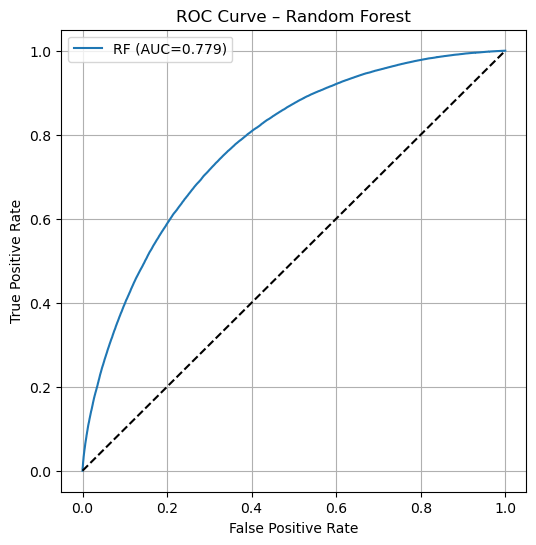

In [69]:
fpr, tpr, _ = roc_curve(y_test, y_proba_rf)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"RF (AUC={roc_auc_rf:.3f})")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Random Forest")
plt.legend()
plt.grid(True)
plt.show()

### Referentni (baseline) model – Dummy klasifikator

Kao referentni baseline koristi se Dummy klasifikator sa strategijom `most_frequent`, koji uvek predviđa najčešću klasu u trening skupu.  
Ovaj model ne koristi nikakve ulazne promenljive i služi kao donja granica performansi.

Poređenjem rezultata Dummy klasifikatora sa stvarnim modelima može se jasno pokazati da predloženi modeli zaista uče korisne obrasce iz podataka.


In [70]:
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)

pred_dummy = dummy.predict(X_test)

print("Dummy Accuracy:", accuracy_score(y_test, pred_dummy))
print("Dummy F1:", f1_score(y_test, pred_dummy))

Dummy Accuracy: 0.5840305365524202
Dummy F1: 0.0


### Primena modela na novim podacima

U ovoj sekciji prikazana je primena obučenog Random Forest modela na pojedinačnom primeru iz test skupa.  
Model predviđa da li će prodaja određenog artikla u određenoj prodavnici biti veća u odnosu na prodaju pre sedam dana (`sales_up`), kao i pripadajuću verovatnoću te predikcije.


In [71]:
sample = X_test.sample(1, random_state=42)

pred = rf.predict(sample)[0]
prob = rf.predict_proba(sample)[0, 1]

print("Predikcija (sales_up):", pred)
print("Verovatnoća rasta prodaje:", round(prob, 3))

Predikcija (sales_up): 1
Verovatnoća rasta prodaje: 0.571


## LightGBM

In [74]:
lgbm = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42
)

In [75]:
lgbm.fit(X_train, y_train)

y_pred_lgbm = lgbm.predict(X_test)
y_proba_lgbm = lgbm.predict_proba(X_test)[:, 1]

[LightGBM] [Info] Number of positive: 108650, number of negative: 146918
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008685 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1711
[LightGBM] [Info] Number of data points in the train set: 255568, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.425131 -> initscore=-0.301743
[LightGBM] [Info] Start training from score -0.301743


In [76]:
acc_lgbm = accuracy_score(y_test, y_pred_lgbm)
f1_lgbm = f1_score(y_test, y_pred_lgbm)
roc_lgbm = roc_auc_score(y_test, y_proba_lgbm)

print("LightGBM results:")
print(f"Accuracy : {acc_lgbm:.4f}")
print(f"F1-score : {f1_lgbm:.4f}")
print(f"ROC-AUC  : {roc_lgbm:.4f}")

LightGBM results:
Accuracy : 0.7133
F1-score : 0.6367
ROC-AUC  : 0.7822
